# Food101 data visulaization

In [1]:
import torch
from torch import nn

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [3]:
# !nvidia-smi

## Dataset and DataLoader

In [4]:
from torchvision import datasets
from torchvision import transforms

data_transform = transforms.Compose([
  transforms.Resize(size = (232,232)),
  transforms.RandomCrop(size = (224,224)),
  transforms.RandomHorizontalFlip(p = 0.5),
  transforms.TrivialAugmentWide(num_magnitude_bins = 31),
  transforms.ToTensor()
])

train_food = datasets.Food101(
    root = 'data',
    split = 'train',
    transform = data_transform,
    download = True,
    target_transform = None
)

test_food = datasets.Food101(
    root = 'data',
    split = 'test',
    transform = data_transform,
    download = True,
    target_transform = None
)

100%|██████████| 5.00G/5.00G [02:56<00:00, 28.4MB/s] 


In [5]:
len(train_food), len(test_food)

(75750, 25250)

In [6]:
class_names = train_food.classes

In [7]:
img, label = train_food[0]
img.shape, label

(torch.Size([3, 224, 224]), 23)

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

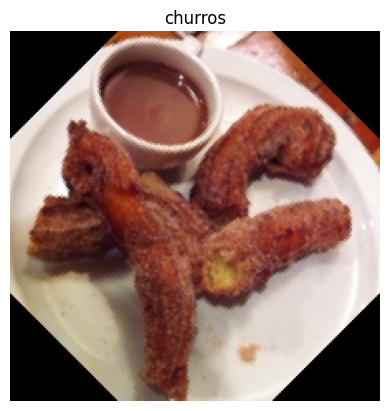

In [8]:
import matplotlib.pyplot as plt

plt.imshow(img.permute(1,2,0))
plt.title(class_names[label])
plt.axis(False)

### Visualizing random data samples

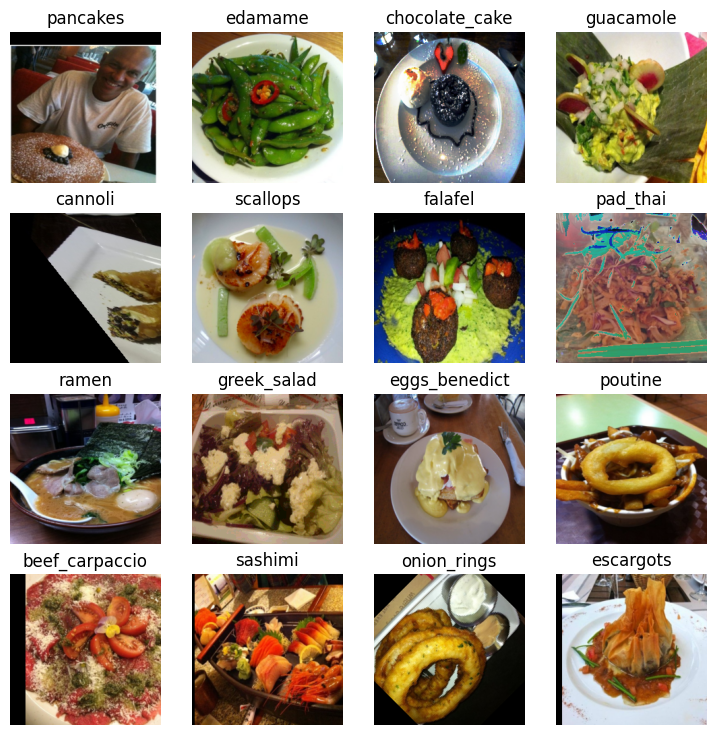

In [9]:
torch.manual_seed(42)

fig = plt.figure(figsize=(9,9))
rows, cols = 4, 4

for i in range(1, rows*cols + 1):
  rand_idx = torch.randint(1, len(train_food), size = [1]).item()
  img, label = train_food[rand_idx]
  plt.subplot(rows, cols, i)
  plt.imshow(img.permute(1,2,0))
  plt.title(class_names[label])
  plt.axis(False)

In [10]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_food,
                          batch_size = 32,
                          shuffle = True,
                          pin_memory = True)

test_loader = DataLoader(test_food,
                         batch_size = 32,
                         shuffle = False,
                         pin_memory = True)

train_loader, test_loader

(<torch.utils.data.dataloader.DataLoader at 0x7d096c14ad80>,
 <torch.utils.data.dataloader.DataLoader at 0x7d096d199b80>)

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

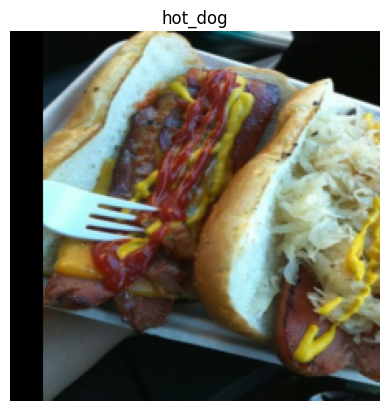

In [11]:
img, label = next(iter(train_loader))

img.shape, label.shape

img0 = img[0]
label0= label[0]

plt.imshow(img0.permute(1,2,0))
plt.title(class_names[label0])
plt.axis(False)